In [32]:
!pip install pandas matplotlib scikit-learn wandb nbformat

In [33]:
# Cell 1
import pandas as pd
import numpy as np
import gzip
import json
import urllib.request
import matplotlib.pyplot as plt
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Evaluation libraries
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

print("Libraries loaded successfully!")
print("Scikit-learn is ready for Naive Bayes.")

Libraries loaded successfully!
Scikit-learn is ready for Naive Bayes.


In [34]:
# Cell 2
import os

url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
file_name = "All_Beauty.jsonl.gz"

if os.path.exists(file_name):
    print(f"'{file_name}' already exists, skipping download.")
else:
    print("Downloading dataset (this may take a moment)...")
    urllib.request.urlretrieve(url, file_name)
    print("Download complete.")

print("Parsing JSONL.GZ file...")
data = []

# Open the compressed file and read line by line
with gzip.open(file_name, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # Limiting to 100,000 rows to prevent RAM overload.
        # Remove or increase this limit if your machine has high memory.
        #if i >= 100000:
        #    break
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"Loaded {len(df)} records.")
df.head(3)

'All_Beauty.jsonl.gz' already exists, skipping download.
Parsing JSONL.GZ file...
Loaded 701528 records.


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True


In [35]:
# Cell 3 (Updated with Balancing Pipeline and 3-Star Count)
from sklearn.utils import resample
import pandas as pd

def preprocess_and_balance_data(df, random_seed=42):
    # Combine title and text to give models maximum context
    df = df.copy()
    df['full_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

    # Drop rows that are completely empty
    df = df[df['full_text'].str.strip() != ""]

    # Count how many 3-star reviews exist before dropping them
    num_dropped_3_star = len(df[df['rating'] == 3.0])

    # Filter out 3-star reviews for binary classification
    df = df[df['rating'] != 3.0]

    # Create binary sentiment labels (4 & 5 stars -> 1, 1 & 2 stars -> 0)
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x > 3 else 0)

    # Separate the reviews into majority and minority classes
    positive_reviews = df[df['sentiment'] == 1]
    negative_reviews = df[df['sentiment'] == 0]

    min_class_size = min(len(positive_reviews), len(negative_reviews))

    # Downsample the classes to match the minimum class size
    pos_downsampled = resample(positive_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    neg_downsampled = resample(negative_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    # Combine the downsampled classes back together
    balanced_df = pd.concat([pos_downsampled, neg_downsampled])

    # Shuffle the dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

    # We now return the dropped count as well
    return balanced_df, pos_downsampled, neg_downsampled, num_dropped_3_star

print("Balancing the dataset...")
balanced_df, pos_df, neg_df, dropped_count = preprocess_and_balance_data(df)

print(f"Dataset balanced successfully!")
print(f"Total 3-star (neutral) reviews dropped: {dropped_count}")
print(f"Total reviews kept for training: {len(balanced_df)}")
print(f"Positive reviews: {len(pos_df)} | Negative reviews: {len(neg_df)}")

# Extract the features (X) and labels (y) for Cell 4 to use
texts = balanced_df['full_text'].values
labels = balanced_df['sentiment'].values

Balancing the dataset...
Dataset balanced successfully!
Total 3-star (neutral) reviews dropped: 56307
Total reviews kept for training: 290228
Positive reviews: 145114 | Negative reviews: 145114


In [36]:
# Cell 4
# Split into 75% training data and 25% testing data
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

print("Fitting TF-IDF vectorizer...")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training data shape: {X_train_tfidf.shape}")
print(f"Testing data shape: {X_test_tfidf.shape}")

Fitting TF-IDF vectorizer...
Training data shape: (217671, 15000)
Testing data shape: (72557, 15000)


In [37]:
# Cell 5
model = MultinomialNB(alpha=1.0)

print("Naive Bayes model created successfully!")
print(model)

Naive Bayes model created successfully!
MultinomialNB()


In [38]:
# Cell 6
print("Starting model training...")

model.fit(X_train_tfidf, y_train)

print("Training complete!")

Starting model training...
Training complete!


In [39]:
# Cell 7
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

print("--- Naive Bayes Model Performance ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

--- Naive Bayes Model Performance ---
              precision    recall  f1-score   support

    Negative       0.93      0.95      0.94     36279
    Positive       0.95      0.93      0.94     36278

    accuracy                           0.94     72557
   macro avg       0.94      0.94      0.94     72557
weighted avg       0.94      0.94      0.94     72557



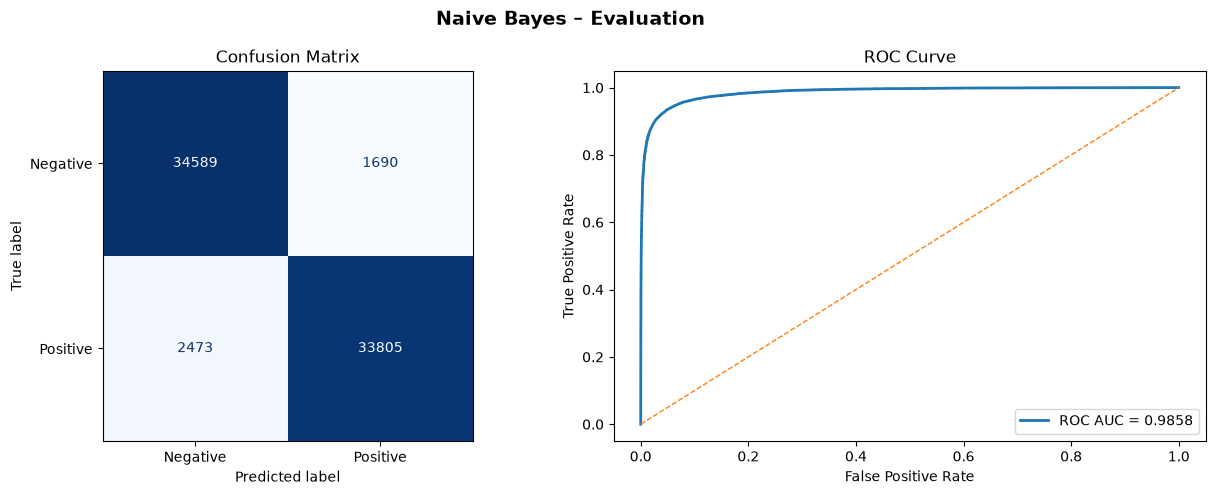

In [40]:
# Cell 8
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Naive Bayes – Evaluation", fontsize=14, fontweight="bold")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [41]:
# Cell 9
def predict_sentiment(review_text):
    # Convert raw review text into TF-IDF format
    review_tfidf = vectorizer.transform([review_text])

    # Predict sentiment
    pred = model.predict(review_tfidf)[0]
    proba = model.predict_proba(review_tfidf)[0][1]

    sentiment = "Positive" if pred == 1 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment}")
    print(f"Positive Probability: {proba:.4f}\n")


predict_sentiment("These shoes look amazing and fit perfectly. Best purchase ever!")
predict_sentiment("Terrible quality. The fabric ripped after one wash. Do not buy.")
predict_sentiment("It's okay, but honestly a little overpriced for what you get.")

Review: 'These shoes look amazing and fit perfectly. Best purchase ever!'
Sentiment: Positive
Positive Probability: 0.9947

Review: 'Terrible quality. The fabric ripped after one wash. Do not buy.'
Sentiment: Negative
Positive Probability: 0.0024

Review: 'It's okay, but honestly a little overpriced for what you get.'
Sentiment: Negative
Positive Probability: 0.1261



In [42]:
# Cell 10 - Weights & Biases Logging

import wandb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt

# Close previous run if one exists
wandb.finish()

# Start a new W&B run
run = wandb.init(
    entity="aiml2026",
    project="amazon-sentiment-analysis",
    group="naive-bayes",
    job_type="train",
    name="naive-bayes",
    tags=["naive-bayes", "tfidf"],
    config={
        "model": "Multinomial Naive Bayes",
        "alpha": 1.0,
        "tfidf_max_features": 15000,
        "ngram_range": "(1,2)",
        "train_size": len(X_train),
        "test_size": len(X_test),
    }
)

# Predictions
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc_value = roc_auc_score(y_test, y_proba)

# Log metrics
wandb.log({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc_value
})

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Negative", "Positive"]
).plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix – Naive Bayes")
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.close(fig)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig2, ax2 = plt.subplots(figsize=(5, 4))

ax2.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_value:.4f}")
ax2.plot([0, 1], [0, 1], linestyle="--")

ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve – Naive Bayes")
ax2.legend()

wandb.log({"roc_curve": wandb.Image(fig2)})
plt.close(fig2)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc_value)

wandb.finish()

Accuracy : 0.9426244194219717
Precision: 0.9523876602338357
Recall   : 0.9318319642758697
F1 Score : 0.9419976871525504
ROC AUC  : 0.9858261435358595


Accuracy,▁
F1,▁
Precision,▁
ROC_AUC,▁
Recall,▁
Accuracy,0.94262
F1,0.942
Precision,0.95239
ROC_AUC,0.98583
Recall,0.93183
